# This python notebook is designed to collect all the detections, figures, and validation results from the model training process. It will also apply data validation and color-coding to the Excel scorecard for easier interpretation of results.

In [41]:
# Importing necessary libraries
#==========================================
import os
import re
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
import json
import openpyxl
from openpyxl.worksheet.datavalidation import DataValidation
from openpyxl.styles import PatternFill
from openpyxl.formatting.rule import CellIsRule
from datetime import datetime, timedelta


In [42]:
# Setting up the base directory and mapping the paths for the three years
# Mapping the site numbers to their corresponding SongMeter IDs for 2025
# ==========================================
BASE_DETECTIONS_DIR = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections'

YEAR_PATHS = {
    "2023": os.path.join(BASE_DETECTIONS_DIR, "2023"),
    "2024": os.path.join(BASE_DETECTIONS_DIR, "2024"),
    "2025": os.path.join(BASE_DETECTIONS_DIR, "2025")
}

OUTPUT_SUMMARY_DIR = os.path.join(BASE_DETECTIONS_DIR, "Summary_Reports_GitHub")
os.makedirs(OUTPUT_SUMMARY_DIR, exist_ok=True)

# 2025 had two deployment periods, S1 and S2, so we are correctly mapping 
# the site numbers to their corresponding SongMeter IDs for each deployment period
MAPPING_S1 = {
    1: "TU016", 3: "TU007", 4: "TU015", 5: "TU011", 6: "TU003", 
    8: "TU026", 9: "TU025", 10: "TU001", 11: "TU020", 12: "TU009", 
    13: "TU017", 14: "TU028", 15: "TU006", 16: "TU002", 17: "TU022", 18: "TU029"
}

MAPPING_S2 = {
    1: "TU026", 2: "TU011", 3: "TU027", 4: "TU004", 5: "TU002", 
    6: "TU022", 7: "TU007", 8: "TU013", 9: "TU014", 10: "TU012", 
    11: "TU019", 12: "TU010", 13: "TU023", 14: "TU024", 15: "TU005", 
    16: "TU018", 17: "TU008", 18: "TU021"
}

In [43]:
# Extracts the survey night from the filename and adjusts for the acoustic night 
# So far, spatial variables have not been merged yet to the master file-level dataset
# ==========================================

def extract_survey_night(filename):
    """Extracts YYYYMMDD and adjusts for acoustic night, fixing the SMU prefix bug."""
    if not isinstance(filename, str):
        return None
    
    match = re.search(r'(202[345])[-_]?(\d{2})[-_]?(\d{2})[-_]?(\d{2})?(\d{2})?(\d{2})?', filename)
    if match:
        year, month, day = int(match.group(1)), int(match.group(2)), int(match.group(3))
        hour = int(match.group(4)) if match.group(4) else 12
        try:
            dt = datetime(year, month, day, hour)
            if dt.hour < 12:
                dt = dt - timedelta(days=1)
            return dt.strftime('%Y-%m-%d')
        except ValueError:
            return None
    return None

def determine_cohort(row):
    """Classifies recordings into precise spatiotemporal survey cohorts."""
    yr = str(row['Year'])
    if yr == '2023':
        return '2023_AM'
    elif yr == '2024':
        folder = str(row.get('Folder', '')).upper()
        fname = str(row.get('File_Name', '')).upper()
        sub = str(row.get('Sub_Folder_Path', '')).upper()
        if 'SM' in folder or 'SM' in fname or 'SM' in sub:
            return '2024_SM'
        return '2024_AM'
    elif yr == '2025':
        night_str = row.get('Survey_Night')
        if pd.isna(night_str):
            return '2025_S1'
        night = pd.to_datetime(night_str)
        if night < pd.Timestamp('2025-03-20'):
            return '2025_S1'
        else:
            return '2025_S2'
    return yr

def resolve_site_id(row):
    """Unifies all naming conventions (AM_02, SM_02, S1/S2 numbers) into standardized TU plot codes."""
    yr = str(row['Year'])
    cohort = row['Cohort']
    raw_folder = str(row.get('Folder', '')).strip()
    sub_path = str(row.get('Sub_Folder_Path', '')).strip()
    
    target_str = raw_folder if raw_folder else sub_path
    
    if yr in ['2023', '2024']:
        match = re.search(r'(AM|SM)[_-]?(\d+)', target_str, re.IGNORECASE)
        if match:
            num = int(match.group(2))
            return f"TU{num:03d}"
        # Fallback check on filename if folder didn't capture it
        match_fn = re.search(r'(AM|SM)[_-]?(\d+)', str(row.get('File_Name', '')), re.IGNORECASE)
        if match_fn:
            num = int(match_fn.group(2))
            return f"TU{num:03d}"
        return target_str
        
    elif yr == '2025':
        clean_str = target_str.replace('SM_', '').replace('SM-', '').replace('_corrupted', '')
        try:
            sm_num = int(clean_str)
        except ValueError:
            # Try parsing from filename if folder fails
            match_num = re.search(r'(\d+)', target_str)
            sm_num = int(match_num.group(1)) if match_num else 0
            
        if cohort == '2025_S1':
            return MAPPING_S1.get(sm_num, f"TU_S1_{sm_num}")
        else:
            return MAPPING_S2.get(sm_num, f"TU_S2_{sm_num}")
            
    return target_str

In [44]:
# Compiles all the csv outputs from the three years into a single master dataframe
# ==========================================

print("🚀 Starting Model V6 Bioacoustic Data Compilation...")
all_files_list = []

for year_label, year_folder in YEAR_PATHS.items():
    if not os.path.exists(year_folder):
        print(f"⚠️ Warning: Path for {year_label} does not exist: {year_folder}")
        continue
        
    csv_files = glob.glob(os.path.join(year_folder, "**/*.csv"), recursive=True)
    print(f"📦 Found {len(csv_files)} CSV report(s) in {year_label}")
    
    for filepath in csv_files:
        try:
            df = pd.read_csv(filepath)
            if df.empty or 'Saccopteryx_Present' not in df.columns:
                continue
            
            # Ensure proper boolean parsing
            df['Saccopteryx_Present'] = df['Saccopteryx_Present'].astype(str).str.upper().isin(['TRUE', '1', '1.0'])
            df['Year'] = year_label
            
            # Extract survey night for temporal grouping and 2025 cohort splitting
            df['Survey_Night'] = df['File_Name'].apply(extract_survey_night)
            
            all_files_list.append(df)
        except Exception as e:
            print(f"⚠️ Error loading {os.path.basename(filepath)}: {e}")

if not all_files_list:
    print("❌ No data loaded. Check your filepaths!")
    exit(1)

master_df = pd.concat(all_files_list, ignore_index=True)

# Assign cohorts and resolve unified site IDs
master_df['Cohort'] = master_df.apply(determine_cohort, axis=1)
master_df['Point'] = master_df.apply(resolve_site_id, axis=1)

print(f"✅ Loaded {len(master_df):,} total file records across all years for Model V6!")

# Save Master File-Level Dataset
master_csv_path = os.path.join(OUTPUT_SUMMARY_DIR, "All_File_Level_Detections_2023_2025.csv")
#master_df.to_csv(master_csv_path, index=False)
#print(f"💾 Master V6 file-level dataset saved to: {master_csv_path}")

🚀 Starting Model V6 Bioacoustic Data Compilation...
📦 Found 25 CSV report(s) in 2023
📦 Found 43 CSV report(s) in 2024
📦 Found 34 CSV report(s) in 2025
✅ Loaded 157,335 total file records across all years for Model V6!


💾 Aggregated site-level heatmap summary CSV saved
🎨 Rendering Model V6 Spatiotemporal Heatmap...


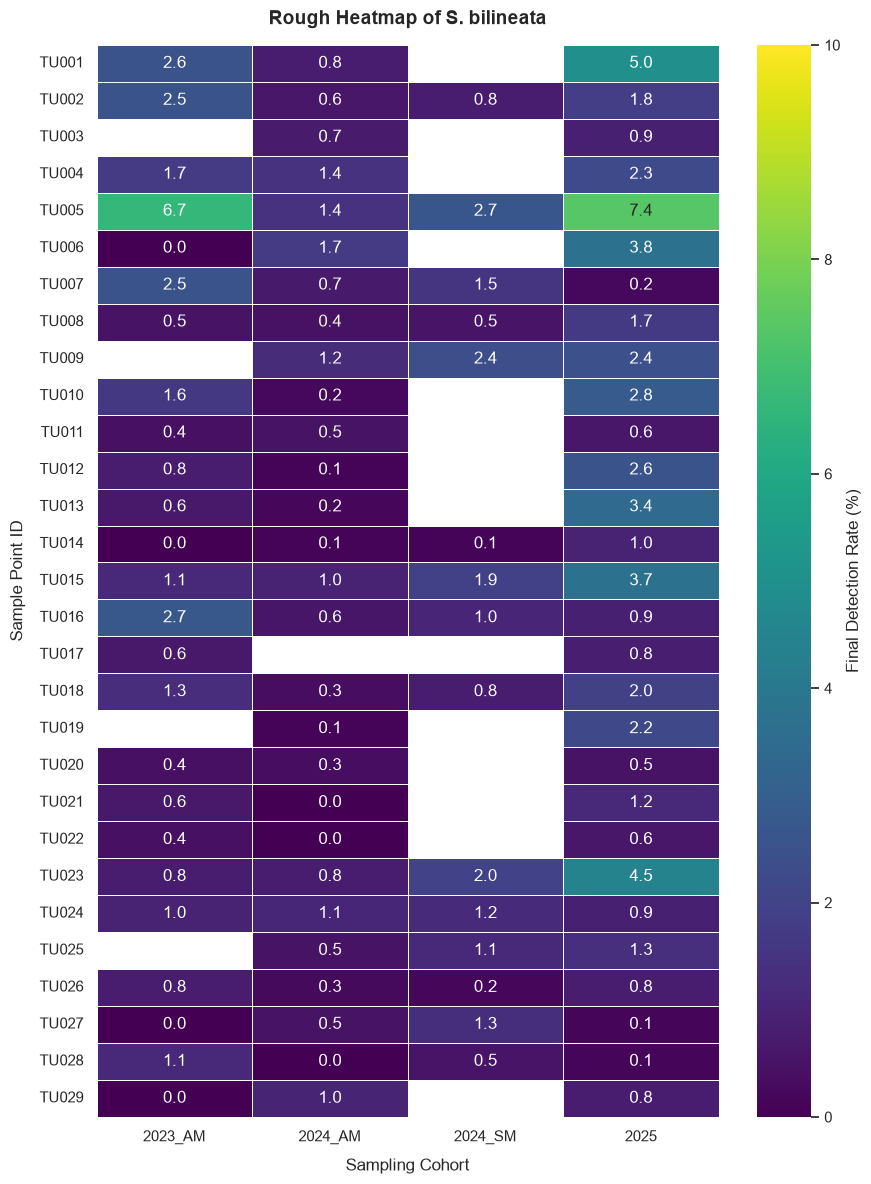

✨ Model V6 heatmap saved 
🏁 Processing complete!


In [45]:
# Calculate detection rates per site and cohort for the heatmap visualization
# Merge 2025 S1 and S2 cohorts into a single '2025' column for the heatmap
# ==========================================
master_df['Cohort'] = master_df['Cohort'].apply(
    lambda c: '2025' if str(c).startswith('2025') else c
)

cohort_summary = master_df.groupby(['Point', 'Cohort']).agg(
    Total_Recordings=('Saccopteryx_Present', 'count'),
    Positive_Recordings=('Saccopteryx_Present', 'sum')
).reset_index()

cohort_summary['Final_Detection_%'] = (cohort_summary['Positive_Recordings'] / cohort_summary['Total_Recordings']) * 100

# Updated chronological cohort order with unified 2025
cohort_order = ['2023_AM', '2024_AM', '2024_SM', '2025']
cohort_summary['Cohort'] = pd.Categorical(cohort_summary['Cohort'], categories=cohort_order, ordered=True)

all_tu_sites = [f"TU{i:03d}" for i in range(1, 30)]
filtered_summary = cohort_summary[cohort_summary['Point'].isin(all_tu_sites)]

# Pivot table for heatmap (Rows = True Points, Columns = Sampling Cohorts)
heatmap_data = filtered_summary.pivot(index='Point', columns='Cohort', values='Final_Detection_%')
heatmap_data = heatmap_data.reindex(index=all_tu_sites, columns=cohort_order)

summary_csv_out = os.path.join(OUTPUT_SUMMARY_DIR, "Aggregated_Site_Level_Summary_2025_merged.csv")
#heatmap_data.to_csv(summary_csv_out)
print(f"💾 Aggregated site-level heatmap summary CSV saved")# to: {summary_csv_out}")

# Heatmap for 2023, 2024, AM, 2024, SM, and combined 2025
# ==========================================
print("🎨 Rendering Model V6 Spatiotemporal Heatmap...")
sns.set_theme(style="white")

plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    vmax=10.0,
    linewidths=.5,
    mask=heatmap_data.isna(),
    cbar_kws={'label': 'Final Detection Rate (%)'}
)

plt.title("Rough Heatmap of S. bilineata", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sampling Cohort", fontsize=12, labelpad=10)
plt.ylabel("Sample Point ID", fontsize=12, labelpad=10)
plt.tight_layout()

heatmap_img_path = os.path.join(OUTPUT_SUMMARY_DIR, "Rough_Heatmap_2025_merged.png")
#plt.savefig(heatmap_img_path, dpi=300)
plt.show()

print(f"✨ Model V6 heatmap saved ")# to: {heatmap_img_path}")
print("🏁 Processing complete!")

In [46]:
# Merging with the spatial variables and building 3 level summaries for GLMM analysis
# ==========================================
print("🚀 Starting the 3-Tier Data Merge (Sanity-Check Edition)...")

master_df = pd.read_csv('/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/All_File_Level_Detections_2023_2025.csv', low_memory=False)
spatial_df = pd.read_excel('/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Turmalina_Mombak_Spatial_Variables.xlsx')

# Drop duplicate columns in spatial_df to keep the merge incredibly clean 
spatial_df = spatial_df.drop(columns=['Point', 'Year'], errors='ignore')

# Create a master point year key for both datasets to merge with the spatial variables
master_df['Year'] = master_df['Year'].astype(str)
master_df['Point_year'] = master_df['Point'] + "_" + master_df['Year']

# We want to add a column for hardware type (AM or SM) based on the folder name, and handle any unexpected cases
master_df['Hardware'] = master_df['Folder'].astype(str).str[:2].str.upper()
master_df['Hardware'] = master_df['Hardware'].apply(lambda x: x if x in ['AM', 'SM'] else 'Unknown')

# Merge datasets with left join to keep all the master file records and using Point_year as the primary key
merged_df = pd.merge(master_df, spatial_df, on='Point_year', how='left')

# Calculate exact dynamic days between recording night and planting date
# Set these columns to datetime and calculate the difference in days, no negative values allowed,
# This is so if the sampling night is before the planting date, we don't get negative ages, which would be biologically impossible.
merged_df['Survey_Night'] = pd.to_datetime(merged_df['Survey_Night'])
merged_df['Date_planted'] = pd.to_datetime(merged_df['Date_planted'], errors='coerce')
# Creates a new column for the exact forest age in days, ensuring no negative values are present
merged_df['Exact_Forest_Age_Days'] = (merged_df['Survey_Night'] - merged_df['Date_planted']).dt.days
merged_df['Exact_Forest_Age_Days'] = merged_df['Exact_Forest_Age_Days'].apply( 
    lambda x: max(0, x) if pd.notnull(x) else x
)

# We save three levels of aggregation for GLMM analysis, starting with the full file-level dataset (Level 1), one with forest and one without forest controls
# ==========================================
#merged_df.to_csv('/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_0_Master_Spatial_Merged.csv', index=False)
print(f"✅ Level 0 Exported: {len(merged_df)} total rows. (Contains all columns from spatial spreadsheet and all file level detections!)")


# Now we build two levels - one with controls and one without control forest plots, 
# Filter out the mature forest controls and mystery sites [TU_S1_7] for Level 2 and 3 aggregations
valid_sites_no_controls = merged_df[~merged_df['Point'].isin(['TU_S1_7', 'TU027', 'TU028', 'TU029'])]
valid_sites =             merged_df[~merged_df['Point'].isin(['TU_S1_7'])]

# Now we filter the Level 1 dataframe directly using your valid_sites logic
level1_filtered_df_no_controls = merged_df[~merged_df['Point'].isin(['TU_S1_7', 'TU027', 'TU028', 'TU029'])]
level1_filtered_df =             merged_df[~merged_df['Point'].isin(['TU_S1_7'])]

# Save this clean level 1 without mystery plot and also without controls
#level1_filtered_df_no_controls.to_csv('/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_1_No_Controls.csv', index=False)
#level1_filtered_df.to_csv('/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_1_With_Controls.csv', index=False)

# Print confirmation to check how many rows were dropped
print(f"✅  Level 1 Exported: {len(level1_filtered_df_no_controls)} rows (Dropped {len(merged_df) - len(level1_filtered_df_no_controls)} control rows).")
print(f"✅  Level 1 Exported: {len(level1_filtered_df)} rows (Dropped {len(merged_df) - len(level1_filtered_df)} control rows).")


# Level 2 - combine per survey night to group all recordings from the same night together, and calculate the total number of recordings and positive detections
# ==========================================
# Added 'Date_planted' and dropna=False to keep it visible without losing missing-date sites
night_summary_no_controls = valid_sites_no_controls.groupby(['Point', 'Year', 'Hardware', 'Habitat', 'Date_planted', 'Survey_Night'], dropna=False).agg(
    Total_Recordings=('Saccopteryx_Present', 'count'),
    Positive_Recordings=('Saccopteryx_Present', 'sum'),
    Exact_Forest_Age_Days=('Exact_Forest_Age_Days', 'mean') 
).reset_index()

night_summary = valid_sites.groupby(['Point', 'Year', 'Hardware', 'Habitat', 'Date_planted', 'Survey_Night'], dropna=False).agg(
    Total_Recordings=('Saccopteryx_Present', 'count'),
    Positive_Recordings=('Saccopteryx_Present', 'sum'),
    Exact_Forest_Age_Days=('Exact_Forest_Age_Days', 'mean') 
).reset_index()

#night_summary_no_controls.to_csv("/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_2_Survey_Night_No_Controls.csv", index=False)
#night_summary.to_csv("/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_2_Survey_Night_With_Controls.csv", index=False)
print(f"✅ Level 2 Exported: {len(night_summary)} survey-night rows.")
print(f"✅ Level 2 Exported: {len(night_summary_no_controls)} survey-night rows.")

# Level 3 - combined per site-year to group all recordings from the same site and year together, and calculate the total number of recordings and positive detections
# ==========================================
# Added Date_planted, First_Survey_Night, and Last_Survey_Night for total transparency!
site_summary = valid_sites.groupby(['Point', 'Year', 'Hardware', 'Habitat', 'Date_planted'], dropna=False).agg(
    First_Survey_Night=('Survey_Night', 'min'),
    Last_Survey_Night=('Survey_Night', 'max'),
    Total_Recordings=('Saccopteryx_Present', 'count'),
    Positive_Recordings=('Saccopteryx_Present', 'sum'),
    Average_Forest_Age_Days=('Exact_Forest_Age_Days', 'mean')
).reset_index()

site_summary_no_controls = valid_sites_no_controls.groupby(['Point', 'Year', 'Hardware', 'Habitat', 'Date_planted'], dropna=False).agg(
    First_Survey_Night=('Survey_Night', 'min'),
    Last_Survey_Night=('Survey_Night', 'max'),
    Total_Recordings=('Saccopteryx_Present', 'count'),
    Positive_Recordings=('Saccopteryx_Present', 'sum'),
    Average_Forest_Age_Days=('Exact_Forest_Age_Days', 'mean')
).reset_index()

#site_summary.to_csv("/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_With_Controls.csv", index=False)
#site_summary_no_controls.to_csv("/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_No_Controls.csv", index=False)
print(f"✅ Level 3 Exported: {len(site_summary)} site-year rows.")
print(f"✅ Level 3 Exported: {len(site_summary_no_controls)} site-year rows.")
print("🎉 All done! You can trace the exact dates perfectly now.")

🚀 Starting the 3-Tier Data Merge (Sanity-Check Edition)...
✅ Level 0 Exported: 157335 total rows. (Contains all columns from spatial spreadsheet and all file level detections!)
✅  Level 1 Exported: 138673 rows (Dropped 18662 control rows).
✅  Level 1 Exported: 157334 rows (Dropped 1 control rows).
✅ Level 2 Exported: 733 survey-night rows.
✅ Level 2 Exported: 665 survey-night rows.
✅ Level 3 Exported: 97 site-year rows.
✅ Level 3 Exported: 86 site-year rows.
🎉 All done! You can trace the exact dates perfectly now.


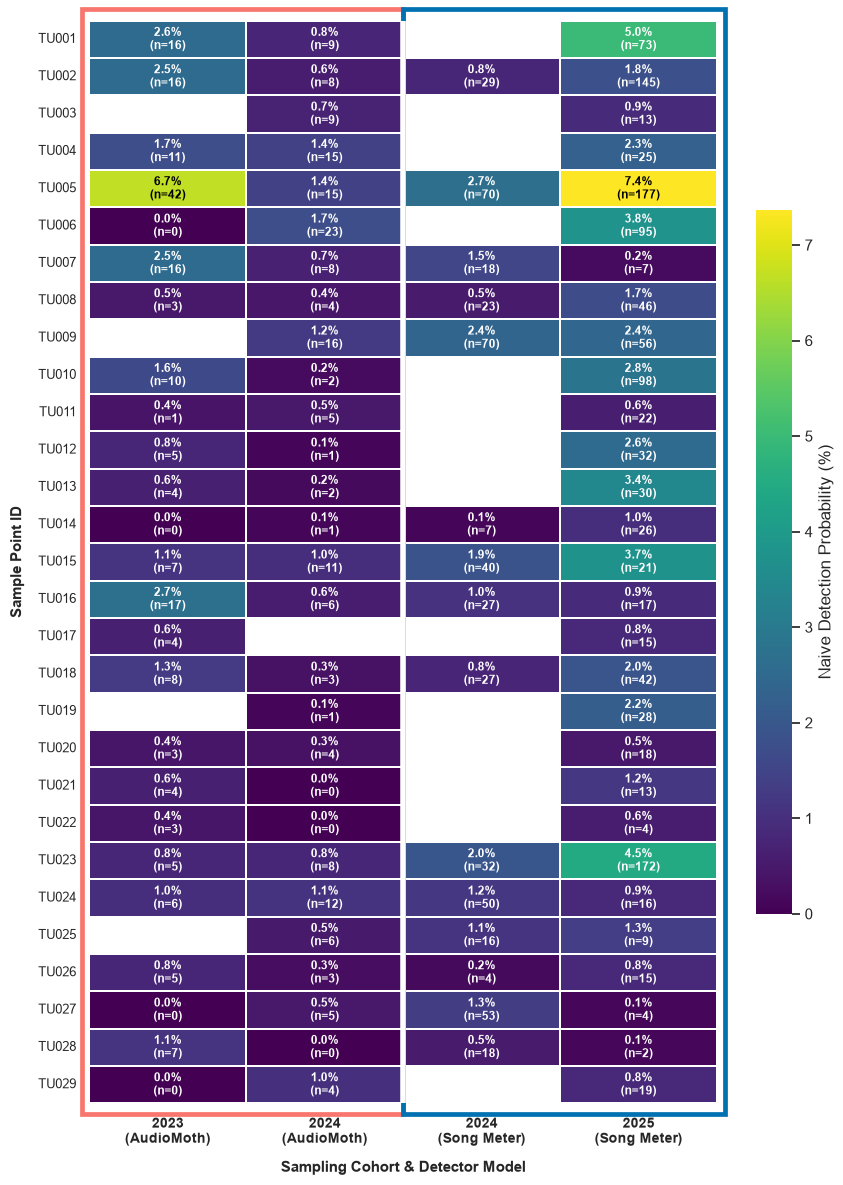

✅ Updated Heatmap successfully saved to: /Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Updated_Heatmap.png


In [47]:
# Making the heatmap with clear edits and a two-line annotation for each cell, showing the detection rate and the number of positive detections
#==========================================
csv_path = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_1_With_Controls.csv'
df_master = pd.read_csv(csv_path)

# 2. Filter out artifact points and map 2025 sub-cohorts
df_clean = df_master[df_master['Point'] != 'TU_S1_7'].copy()

def map_cohort(val):
    if str(val).startswith('2025'):
        return "2025"
    return val

df_clean['Cohort_Plot'] = df_clean['Cohort'].apply(map_cohort)

# Logical check for positive detections
def is_positive(val):
    return str(val).strip() in ["True", "TRUE", "1", "1.0"]

df_heatmap_agg = df_clean.groupby(['Point', 'Cohort_Plot']).agg(
    Total_Files=('Point', 'count'),
    Pos_Files=('Saccopteryx_Present', lambda x: sum(x.apply(is_positive)))
).reset_index()

df_heatmap_agg['Detection_Rate'] = (df_heatmap_agg['Pos_Files'] / df_heatmap_agg['Total_Files']) * 100

# Set the order of the columns
cohort_order = ["2023_AM", "2024_AM", "2024_SM", "2025"]
all_tu_sites = [f"TU{i:03d}" for i in range(1, 30)] 

pivot_rate = df_heatmap_agg.pivot(index='Point', columns='Cohort_Plot', values='Detection_Rate')
pivot_rate = pivot_rate.reindex(index=all_tu_sites, columns=cohort_order)

pivot_pos = df_heatmap_agg.pivot(index='Point', columns='Cohort_Plot', values='Pos_Files')
pivot_pos = pivot_pos.reindex(index=all_tu_sites, columns=cohort_order)

# Create two-line text labels in the cells "Rate%\n(n=Count)"
annot_matrix = np.empty(pivot_rate.shape, dtype=object)
for i in range(pivot_rate.shape[0]):
    for j in range(pivot_rate.shape[1]):
        rate = pivot_rate.iloc[i, j]
        pos = pivot_pos.iloc[i, j]
        if pd.isna(rate) or pd.isna(pos):
            annot_matrix[i, j] = ""
        else:
            annot_matrix[i, j] = f"{rate:.1f}%\n(n={int(pos)})"

# Build Single High-Resolution Heatmap Figure
fig, ax = plt.subplots(figsize=(9.0, 12))
sns.set_theme(style="white")

ax = sns.heatmap(
    pivot_rate,
    annot=annot_matrix,
    fmt="",
    cmap="viridis",
    linewidths=1.2,          # Clean grid lines
    linecolor="white",
    mask=pivot_rate.isna(),
    cbar_kws={'label': 'Naive Detection Probability (%)', 'shrink': 0.65},
    ax=ax
)

# Text contrast color adjustment
for t in ax.texts:
    text_pos = t.get_position()
    col_idx = int(np.floor(text_pos[0]))
    row_idx = int(np.floor(text_pos[1]))
    val = pivot_rate.iloc[row_idx, col_idx]
    if not pd.isna(val) and val > 5.0:
        t.set_color("black")
    else:
        t.set_color("white")
    t.set_weight("bold")
    t.set_fontsize(8.5)


# Bounding boxes for the two device groups (AudioMoth and Song Meter) with a clean vertical white dividing line
# AudioMoth group (Indices 0 & 1): Encloses cols 0 to 2 
ax.add_patch(plt.Rectangle((-0.05, -0.3), 2.05, pivot_rate.shape[0] + 0.6, fill=False, edgecolor="#F8766D", lw=3.4, clip_on=False))
# Song Meter group (Indices 3 & 4): Encloses cols 3 to 5 (starting right after the spacer)
ax.add_patch(plt.Rectangle((2.0, -0.3), 2.05, pivot_rate.shape[0] + 0.6, fill=False, edgecolor="#0072B2", lw=3.4, clip_on=False))
# 7. Draw a clean vertical dividing line between AudioMoth (col 1) and Song Meter (col 2)
ax.axvline(2, color='white', linewidth=4.0)

# Axis Labels and Formatting
ax.set_xticklabels([
    "2023\n(AudioMoth)", 
    "2024\n(AudioMoth)", 
    "2024\n(Song Meter)", 
    "2025\n(Song Meter)"
], fontweight='bold', fontsize=10, rotation=0)

ax.set_xlabel("Sampling Cohort & Detector Model", fontweight='bold', fontsize=11, labelpad=10)
ax.set_ylabel("Sample Point ID", fontweight='bold', fontsize=11, labelpad=10)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()

# Save output
figure_output_path ='/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Updated_Heatmap.png'
#plt.savefig(figure_output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Updated Heatmap successfully saved to: {figure_output_path}")



In [48]:
# Summary of detection rates for both datasets (with and without controls)
#==========================================

def summarize_detection_rates(file_path, label):
    df = pd.read_csv(file_path)
    
    # Calculate row-level proportion and percentage for each site-year deployment
    df['Proportion'] = df['Positive_Recordings'] / df['Total_Recordings']
    df['Percentage'] = df['Proportion'] * 100
    
    # Overall dataset metrics
    total_positives = df['Positive_Recordings'].sum()
    total_recordings = df['Total_Recordings'].sum()
    overall_rate_pct = (total_positives / total_recordings) * 100
    
    # Site-level distribution metrics
    mean_pct = df['Percentage'].mean()
    median_pct = df['Percentage'].median()
    iqr_pct = df['Percentage'].quantile(0.75) - df['Percentage'].quantile(0.25)
    min_pct = df['Percentage'].min()
    max_pct = df['Percentage'].max()
    
    mean_prop = df['Proportion'].mean()
    median_prop = df['Proportion'].median()
    iqr_prop = df['Proportion'].quantile(0.75) - df['Proportion'].quantile(0.25)
    min_prop = df['Proportion'].min()
    max_prop = df['Proportion'].max()

    print(f"=== {label.upper()} ===")
    print(f"Total Positive Recordings: {total_positives:,}")
    print(f"Total Audio Files Analyzed: {total_recordings:,}")
    print(f"Overall Dataset Detection Rate: {overall_rate_pct:.2f}% ({total_positives / total_recordings:.4f})")
    print("-" * 40)
    print("Site-Level Summary Statistics (Percentages):")
    print(f"  Mean:   {mean_pct:.2f}%")
    print(f"  Median: {median_pct:.2f}%")
    print(f"  IQR:    {iqr_pct:.2f}%")
    print(f"  Min:    {min_pct:.2f}%")
    print(f"  Max:    {max_pct:.2f}%")
    print("-" * 40)
    print("Site-Level Summary Statistics (Proportions / Decimals):")
    print(f"  Mean:   {mean_prop:.4f}")
    print(f"  Median: {median_prop:.4f}")
    print(f"  IQR:    {iqr_prop:.4f}")
    print(f"  Min:    {min_prop:.4f}")
    print(f"  Max:    {max_prop:.4f}\n")

# Run analysis for both datasets
path_with_controls = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_With_Controls.csv'
path_without_controls = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_No_Controls.csv'

summarize_detection_rates(path_with_controls, "With Controls")
summarize_detection_rates(path_without_controls, "Without Controls")



import pandas as pd

def print_cohort_breakdown_by_labels(csv_path, title):
    df = pd.read_csv(csv_path)
    
    # Define the 4 specific subgroups using Year and Hardware logic
    # (Adjust column names if they differ slightly, e.g., 'Year' and 'Hardware')
    subgroups = [
        ("2023 (AudioMoth)", (df['Year'] == 2023) | (df['Year'].astype(str) == '2023')),
        ("2024 (AudioMoth)", ((df['Year'] == 2024) | (df['Year'].astype(str) == '2024')) & (df['Hardware'].astype(str).str.upper() == 'AM')),
        ("2024 (Song Meter)", ((df['Year'] == 2024) | (df['Year'].astype(str) == '2024')) & (df['Hardware'].astype(str).str.upper() == 'SM')),
        ("2025 (Song Meter)", (df['Year'] == 2025) | (df['Year'].astype(str) == '2025'))
    ]
    
    print("=" * 95)
    print(f"  {title.upper()} — COHORT & HARDWARE BREAKDOWN")
    print("=" * 95)
    print(f"  {'Cohort / Regime':<20} | {'Total Det.':<10} | {'Mean (Count | %)':<18} | {'Median (IQR) [Count]'}")
    print("-" * 95)
    
    for label, condition in subgroups:
        sub_df = df[condition]
        
        if sub_df.empty:
            print(f"  {label:<20} | No data found")
            continue
            
        total_det = sub_df['Positive_Recordings'].sum()
        
        mean_val = sub_df['Positive_Recordings'].mean()
        mean_pct = (sub_df['Positive_Recordings'] / sub_df['Total_Recordings']).mean() * 100 if 'Total_Recordings' in sub_df.columns else 0
        
        med_val = sub_df['Positive_Recordings'].median()
        q75 = sub_df['Positive_Recordings'].quantile(0.75)
        q25 = sub_df['Positive_Recordings'].quantile(0.25)
        iqr_val = q75 - q25
        
        mean_str = f"{mean_val:.1f} | {mean_pct:.2f}%"
        med_iqr_str = f"{med_val:.1f} (±{iqr_val:.1f})"
        
        print(f"  {label:<20} | {total_det:<10} | {mean_str:<18} | {med_iqr_str}")
        
    print("=" * 95 + "\n")

# 1. With Controls
path_with_ctrl = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_With_Controls.csv'
print_cohort_breakdown_by_labels(path_with_ctrl, "Dataset: With Controls")

# 2. Without Controls
path_no_ctrl = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_No_Controls.csv'
print_cohort_breakdown_by_labels(path_no_ctrl, "Dataset: Without Controls")



=== WITH CONTROLS ===
Total Positive Recordings: 2,098
Total Audio Files Analyzed: 157,334
Overall Dataset Detection Rate: 1.33% (0.0133)
----------------------------------------
Site-Level Summary Statistics (Percentages):
  Mean:   1.25%
  Median: 0.81%
  IQR:    1.21%
  Min:    0.00%
  Max:    7.37%
----------------------------------------
Site-Level Summary Statistics (Proportions / Decimals):
  Mean:   0.0125
  Median: 0.0081
  IQR:    0.0121
  Min:    0.0000
  Max:    0.0737

=== WITHOUT CONTROLS ===
Total Positive Recordings: 1,986
Total Audio Files Analyzed: 138,673
Overall Dataset Detection Rate: 1.43% (0.0143)
----------------------------------------
Site-Level Summary Statistics (Percentages):
  Mean:   1.35%
  Median: 0.87%
  IQR:    1.29%
  Min:    0.00%
  Max:    7.37%
----------------------------------------
Site-Level Summary Statistics (Proportions / Decimals):
  Mean:   0.0135
  Median: 0.0087
  IQR:    0.0129
  Min:    0.0000
  Max:    0.0737

  DATASET: WITH CONTROL

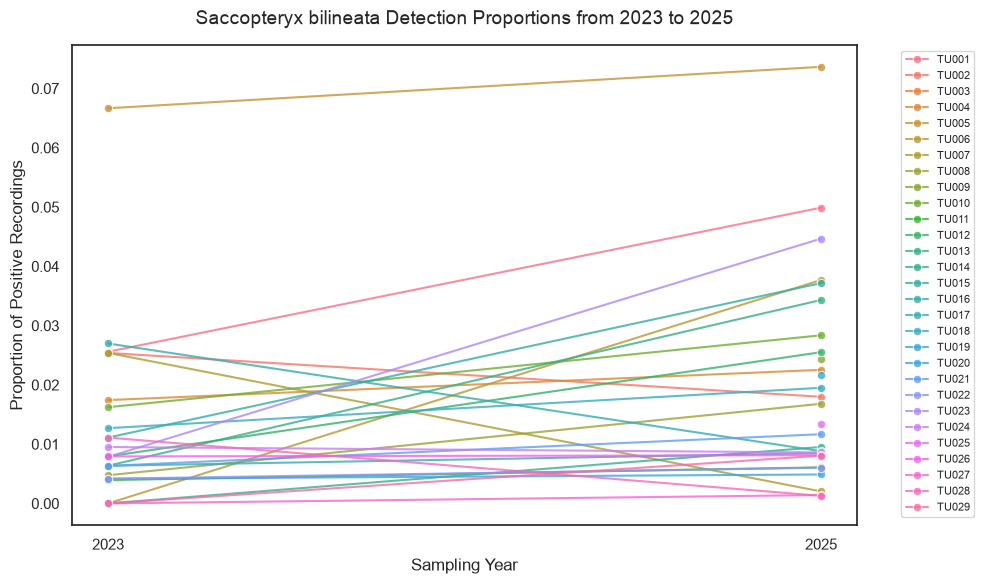

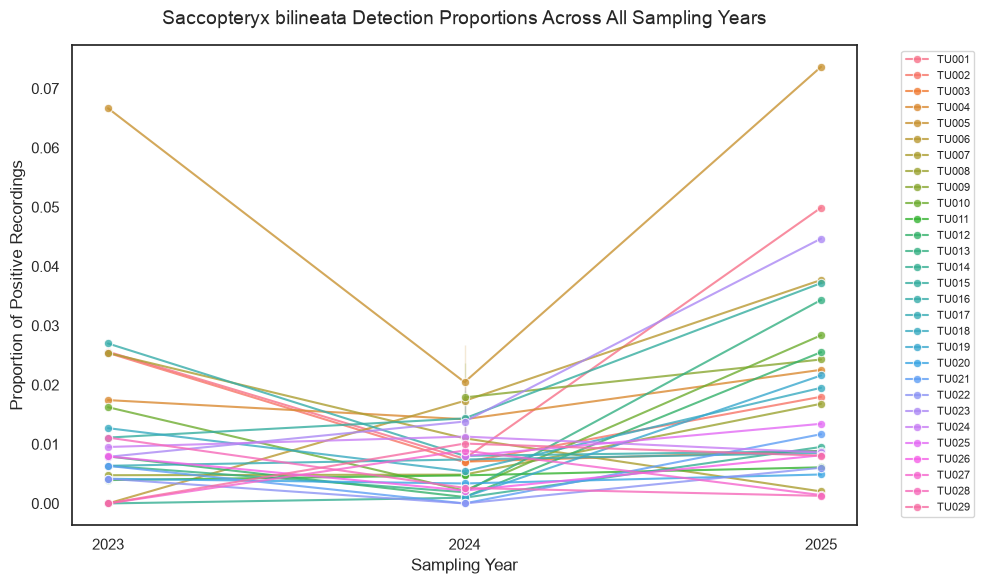

--- TABLE 1: 2023 vs 2025 ---
       2023_Detection_Prop  2025_Detection_Prop  Pct_Change_23_to_25
Point                                                               
TU001               0.0256               0.0499              94.9120
TU002               0.0254               0.0180             -29.1553
TU003                  NaN               0.0089                  NaN
TU004               0.0174               0.0225              29.3139
TU005               0.0667               0.0737              10.4869
TU006               0.0000               0.0377                  inf
TU007               0.0254               0.0020             -92.0224
TU008               0.0048               0.0168             253.0702
TU009                  NaN               0.0243                  NaN
TU010               0.0162               0.0284              74.7265
TU011               0.0039               0.0061              54.6637
TU012               0.0079               0.0255             221.5311
TU01

In [49]:
# A line plot to visualise the detections 2023 to 2025 and then all three years

df_years = pd.read_csv('/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_With_Controls.csv')

# Calculate proportion of positive recordings
df_years['Proportion'] = df_years['Positive_Recordings'] / df_years['Total_Recordings']
# Filter to include ONLY 2023 and 2025
df_23_25 = df_years[df_years['Year'].isin([2023, 2025])]
plt.figure(figsize=(10, 6))

# Create a line plot tracking each 'Point' across 'Year'
sns.lineplot(
    data=df_23_25, 
    x='Year', 
    y='Proportion', 
    hue='Point', 
    marker='o', 
    linewidth=1.5, 
    alpha=0.8
)

plt.title('Saccopteryx bilineata Detection Proportions from 2023 to 2025', fontsize=14, pad=15)
plt.xlabel('Sampling Year', fontsize=12)
plt.ylabel('Proportion of Positive Recordings', fontsize=12)

# Adjust x-axis ticks to ensure only actual survey years show up clearly
plt.xticks([2023, 2025])

# Place the legend outside or clean it up if there are many points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()

#plt.savefig('2023_to_2025_Site_Trajectories.png', dpi=300)
plt.show()

# Create a line plot tracking each 'Point' across 'Year'
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_years, 
    x='Year', 
    y='Proportion', 
    hue='Point', 
    marker='o', 
    linewidth=1.5, 
    alpha=0.8
)

plt.title('Saccopteryx bilineata Detection Proportions Across All Sampling Years', fontsize=14, pad=15)
plt.xlabel('Sampling Year', fontsize=12)
plt.ylabel('Proportion of Positive Recordings', fontsize=12)

# Adjust x-axis ticks to ensure only actual survey years show up clearly
plt.xticks([2023, 2024, 2025])

# Place the legend outside or clean it up if there are many points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()

#plt.savefig('All_Year_Site_Trajectories.png', dpi=300)
plt.show()

# Summary tables of the percentage changes between each year
df = pd.read_csv('/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_3_Site_Year_With_Controls.csv')


df['Proportion'] = df['Positive_Recordings'] / df['Total_Recordings']
df_agg = df.groupby(['Point', 'Year'], as_index=False)['Proportion'].mean()

# Pivot table so each Point is a row and Years are columns
pivot_df = df_agg.pivot(index='Point', columns='Year', values='Proportion')

# TABLE 1: 2023 vs. 2025 (Big Picture Scope)
# ==========================================
table_1 = pd.DataFrame({
    '2023_Detection_Prop': pivot_df[2023],
    '2025_Detection_Prop': pivot_df[2025]
})
table_1['Pct_Change_23_to_25'] = ((table_1['2025_Detection_Prop'] - table_1['2023_Detection_Prop']) / table_1['2023_Detection_Prop']) * 100

print("--- TABLE 1: 2023 vs 2025 ---")
print(table_1.round(4))


# TABLE 2: Full Multi-Year Trajectory & % Changes
# ==========================================
table_2 = pd.DataFrame({
    '2023': pivot_df[2023],
    '2024': pivot_df[2024],
    '2025': pivot_df[2025]
})
table_2['Pct_Change_23_24'] = ((table_2['2024'] - table_2['2023']) / table_2['2023']) * 100
table_2['Pct_Change_24_25'] = ((table_2['2025'] - table_2['2024']) / table_2['2024']) * 100
table_2['Overall_Pct_Change_23_25'] = ((table_2['2025'] - table_2['2023']) / table_2['2023']) * 100

print("\n--- TABLE 2: Multi-Year Breakdown ---")
print(table_2.round(4))

#table_1.to_csv('Table1_23_25_Summary.csv')
#table_2.to_csv('Table2_MultiYear_Summary.csv')

# Validation below

In [ ]:
import os
import shutil
import pandas as pd
import json
import openpyxl
from openpyxl.worksheet.datavalidation import DataValidation
from openpyxl.styles import PatternFill
from openpyxl.formatting.rule import CellIsRule

# ==============================================================================
# PATH CONFIGURATION
# ==============================================================================
PARENT_FOLDERS = [
    "/Volumes/AcousticData/AcousticData_2023/Mombak_Turmalina_2023/BatData_Turmalina_2023", 
    "/Volumes/AcousticData/AcousticData_2024/AcousticData_Turmalina_2024/BatData_Turmalina_2024",
    "/Volumes/AcousticData/AcousticData_2025/AcousticData_Turmalina_2025_Sample1/BatData_Turmalina_2025_Sample1",
    "/Volumes/AcousticData/AcousticData_2025/AcousticData_Turmalina_2025_Sample2/BatData_Turmalina_2025_Sample2"
]

BASE_DIR = "/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub"
MASTER_CSV_PATH = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Level_1_With_Controls.csv'

AUDIT_DIR = os.path.join(BASE_DIR, "Validation_Audit")
EXCEL_SCORECARD_PATH = os.path.join(AUDIT_DIR, "V6_Manual_Validation_Scorecard.xlsx")
CACHE_PATH = os.path.join(AUDIT_DIR, "discovered_folders_cache.json")
OUTPUT_DIR = os.path.join(AUDIT_DIR, "Kaleidoscope_Files")

os.makedirs(AUDIT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================================================================
# AUDIO DIRECTORY DISCOVERY
# ==============================================================================
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r') as f:
        active_folders = json.load(f)
    print(f"✅ Loaded {len(active_folders)} audio directories from cache.")
else:
    print("🔍 Scanning drives for audio folders (this may take a minute)...")
    active_folders = []
    for parent in PARENT_FOLDERS:
        if os.path.exists(parent):
            for root, dirs, files in os.walk(parent):
                if any(f.lower().endswith('.wav') for f in files):
                    active_folders.append(root)
    with open(CACHE_PATH, 'w') as f:
        json.dump(active_folders, f)
    print(f"✅ Discovered and cached {len(active_folders)} audio directories.")

# ==============================================================================
# SCORECARD GENERATION (REBUILDING THE TIERED SAMPLE)
# ==============================================================================
print("⚙️ Generating new V6 Stratified Validation Scorecard...")
df_master = pd.read_csv(MASTER_CSV_PATH)
sampled_rows = []

for (year, site_id), group in df_master.groupby(['Year', 'Point']):
    t1 = group[group['Max_Confidence'] >= 0.98]
    s1 = t1.sample(n=min(2, len(t1)), random_state=42) if not t1.empty else pd.DataFrame()
    if not s1.empty: s1['Audit_Tier'] = '1_High_Confidence_Positive_>0.98'
    
    t2 = group[(group['Max_Confidence'] >= 0.95) & (group['Max_Confidence'] < 0.98)]
    s2 = t2.sample(n=min(3, len(t2)), random_state=42) if not t2.empty else pd.DataFrame()
    if not s2.empty: s2['Audit_Tier'] = '2_Borderline_Positive_0.95-0.98'
    
    t3 = group[(group['Max_Confidence'] >= 0.90) & (group['Max_Confidence'] < 0.95)]
    s3 = t3.sample(n=min(3, len(t3)), random_state=42) if not t3.empty else pd.DataFrame()
    if not s3.empty: s3['Audit_Tier'] = '3_Near_Miss_Negative_0.90-0.95'
    
    t4 = group[(group['Max_Confidence'] >= 0.80) & (group['Max_Confidence'] < 0.90)]
    s4 = t4.sample(n=min(2, len(t4)), random_state=42) if not t4.empty else pd.DataFrame()
    if not s4.empty: s4['Audit_Tier'] = '4_Moderate_Confusion_0.80-0.90'
    
    t5 = group[group['Max_Confidence'] < 0.20]
    s5 = t5.sample(n=min(1, len(t5)), random_state=42) if not t5.empty else pd.DataFrame()
    if not s5.empty: s5['Audit_Tier'] = '5_Clear_Negative_<0.20'
    
    sampled_rows.extend([s1, s2, s3, s4, s5])
    
df_scorecard = pd.concat([df for df in sampled_rows if not df.empty], ignore_index=True)

df_scorecard['Human_Verdict'] = ''  
df_scorecard['Noise_Type_If_FP'] = '' 
df_scorecard['Auditor_Notes'] = ''

df_scorecard.to_excel(EXCEL_SCORECARD_PATH, index=False, engine='openpyxl')

# ==============================================================================
# KALEIDOSCOPE FILE EXTRACTION (WITH UNIQUE PREFIXING & CRASH PROTECTION)
# ==============================================================================
def locate_raw_audio(filename, site_id, year, active_folders):
    clean_fn = filename if filename.lower().endswith('.wav') else f"{filename}.wav"
    for folder in active_folders:
        if str(year) in folder and (str(site_id) in folder or str(site_id).replace('_', '') in folder):
            p = os.path.join(folder, clean_fn)
            if os.path.exists(p):
                return p
    for folder in active_folders:
        p = os.path.join(folder, clean_fn)
        if os.path.exists(p):
            return p
    return None

print(f"\n⚙️ Extracting and uniquely renaming {len(df_scorecard)} files for Kaleidoscope...")
copied_count = 0
missing_files = []
hardware_errors = []

for idx, row in df_scorecard.iterrows():
    site_id = row['Point']
    year = row['Year']
    fname = str(row['File_Name'])
    
    source_path = locate_raw_audio(fname, site_id, year, active_folders)
    
    if source_path:
        clean_name = fname if fname.lower().endswith('.wav') else f"{fname}.wav"
        # Unique naming format: SITE_YEAR_FILENAME to avoid collisions!
        unique_filename = f"{site_id}_{year}_{clean_name}"
        dest_path = os.path.join(OUTPUT_DIR, unique_filename)
        
        if not os.path.exists(dest_path):
            try:
                shutil.copy2(source_path, dest_path)
                copied_count += 1
            except OSError as e:
                hardware_errors.append(f"{fname} (Error: {e})")
        else:
            copied_count += 1
            
        if copied_count % 50 == 0:
            print(f"   ... {copied_count} files processed ...")
    else:
        missing_files.append(fname)

# ==============================================================================
# AUTOMATICALLY APPLY EXCEL DATA VALIDATION & COLOR-CODING
# ==============================================================================
print("\n🎨 Applying smart validation rules and color-coding to Excel scorecard...")
wb = openpyxl.load_workbook(EXCEL_SCORECARD_PATH)
ws = wb.active

header_row = [cell.value for cell in ws[1]]
verdict_col_idx = header_row.index('Human_Verdict') + 1  
tier_col_idx = header_row.index('Audit_Tier') + 1        

verdict_letter = openpyxl.utils.get_column_letter(verdict_col_idx)
tier_letter = openpyxl.utils.get_column_letter(tier_col_idx)
max_row = ws.max_row

# Custom Validation Formula ensuring Tiers 1-2 take TP/FP, and Tiers 3-5 take TN/FN
validation_formula = f'=OR(AND(OR(LEFT({tier_letter}2,2)="1_", LEFT({tier_letter}2,2)="2_"), OR({verdict_letter}2="TP", {verdict_letter}2="FP")), AND(OR(LEFT({tier_letter}2,2)="3_", LEFT({tier_letter}2,2)="4_", LEFT({tier_letter}2,2)="5_"), OR({verdict_letter}2="TN", {verdict_letter}2="FN")))'

dv = DataValidation(type="custom", formula1=validation_formula, allow_blank=True)
dv.error ='Wrong Verdict for this Tier!\n\nTiers 1 & 2 only accept TP or FP.\nTiers 3, 4, & 5 only accept TN or FN.'
dv.errorTitle = 'Invalid Selection'
dv.prompt = 'Enter TP/FP for Tiers 1-2, or TN/FN for Tiers 3-5.'
dv.promptTitle = 'Validation Rule'

ws.add_data_validation(dv)
dv.add(f"{verdict_letter}2:{verdict_letter}{max_row}")

# Conditional Formatting Colors (Using correct 6-digit hex codes)
range_str = f"{verdict_letter}2:{verdict_letter}{max_row}"
ws.conditional_formatting.add(range_str, CellIsRule(operator='equal', formula=['"TP"'], stopIfTrue=True, fill=PatternFill(start_color="D4EDDA", end_color="D4EDDA", fill_type="solid")))
ws.conditional_formatting.add(range_str, CellIsRule(operator='equal', formula=['"FP"'], stopIfTrue=True, fill=PatternFill(start_color="F8D7DA", end_color="F8D7DA", fill_type="solid")))
ws.conditional_formatting.add(range_str, CellIsRule(operator='equal', formula=['"TN"'], stopIfTrue=True, fill=PatternFill(start_color="D1ECF1", end_color="D1ECF1", fill_type="solid")))
ws.conditional_formatting.add(range_str, CellIsRule(operator='equal', formula=['"FN"'], stopIfTrue=True, fill=PatternFill(start_color="FFF3CD", end_color="FFF3CD", fill_type="solid")))

wb.save(EXCEL_SCORECARD_PATH)

print("✨ Success! Validation rules and colors applied cleanly to your Excel scorecard.")
print("\n=========================================================")
print(f"✅ ALL DONE! Successfully secured and renamed {copied_count} files.")
print(f"📁 Kaleidoscope Audio Folder ") #: {OUTPUT_DIR}")
print(f"📝 Excel Scorecard (with built-in validation & colors) ")#: {EXCEL_SCORECARD_PATH}")
if missing_files:
    print(f"⚠️ Could not locate {len(missing_files)} files.")
print("=========================================================")

🔍 Scanning drives for audio folders (this may take a minute)...
✅ Discovered and cached 0 audio directories.
⚙️ Generating new V6 Stratified Validation Scorecard...

🎨 Applying smart validation rules and color-coding to Excel scorecard...
✨ Success! Validation rules and colors applied cleanly to your Excel scorecard.



NameError: name 'copied_count' is not defined

    MODEL V6 GROUND-TRUTH AUDIT PERFORMANCE       
  - Total Files Audited : 709
  - True Positives (TP) : 137
  - False Positives (FP): 177
  - True Negatives (TN) : 324
  - False Negatives (FN): 71
--------------------------------------------------
  - Precision (PPV)    : 43.63%
  - Recall (Sensitivity): 65.87%
  - F1-Score           : 52.49%
  - Overall Accuracy   : 65.02%

🔍 False Positive Noise Breakdown:
Series([], Name: count, dtype: int64)


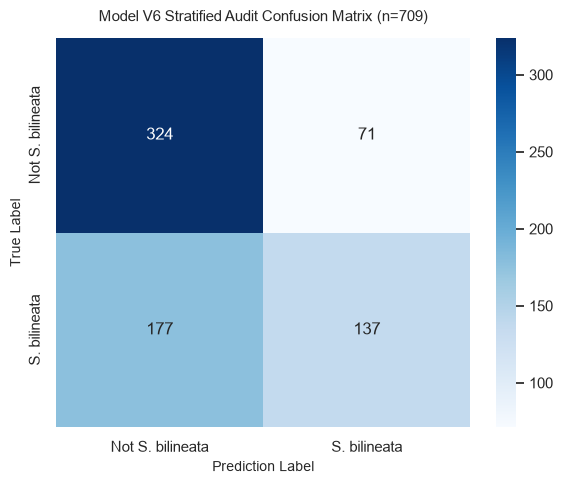

In [ ]:
# VALIDATION GROUND-TRUTH ACCURACY METRIC CALCULATOR
# ==============================================================================
EXCEL_SCORECARD_PATH = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Validation_Audit/V6_Manual_Validation_Scorecard.xlsx'
df_results = pd.read_excel(EXCEL_SCORECARD_PATH)

# Filter for rows with completed verdicts
audited = df_results[df_results['Human_Verdict'].astype(str).str.upper().isin(['TP', 'FP', 'TN', 'FN'])]

tp = len(audited[audited['Human_Verdict'] == 'tp'])
fp = len(audited[audited['Human_Verdict'] == 'fp'])
tn = len(audited[audited['Human_Verdict'] == 'tn'])
fn = len(audited[audited['Human_Verdict'] == 'fn'])

total_audited = tp + fp + tn + fn

if total_audited > 0:
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / total_audited
    
    print("==================================================")
    print("    MODEL V6 GROUND-TRUTH AUDIT PERFORMANCE       ")
    print("==================================================")
    print(f"  - Total Files Audited : {total_audited}")
    print(f"  - True Positives (TP) : {tp}")
    print(f"  - False Positives (FP): {fp}")
    print(f"  - True Negatives (TN) : {tn}")
    print(f"  - False Negatives (FN): {fn}")
    print("--------------------------------------------------")
    print(f"  - Precision (PPV)    : {precision * 100:.2f}%")
    print(f"  - Recall (Sensitivity): {recall * 100:.2f}%")
    print(f"  - F1-Score           : {f1 * 100:.2f}%")
    print(f"  - Overall Accuracy   : {accuracy * 100:.2f}%")
    print("==================================================")
    
    # Display Breakdown of Noise Types if False Positives exist
    if fp > 0 and 'Noise_Type_If_FP' in audited.columns:
        print("\n🔍 False Positive Noise Breakdown:")
        print(audited[audited['Human_Verdict'] == 'FP']['Noise_Type_If_FP'].value_counts())
else:
    print("⚠️ No audited verdicts found in scorecard yet. Run Cell 3 to begin auditing!")


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Audit values from your scorecard
cm_audit = np.array([[tn, fn],   # True Negatives (324), False Negatives (71)
                     [fp, tp]]) # False Positives (177), True Positives (137)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_audit, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not S. bilineata', 'S. bilineata'],
            yticklabels=['Not S. bilineata', 'S. bilineata'])

plt.title("Model V6 Stratified Audit Confusion Matrix (n=709)", fontsize=11, pad=12)
plt.ylabel("True Label", fontsize=10)
plt.xlabel("Prediction Label", fontsize=10)
plt.tight_layout()

# Save figure for your thesis
audit_fig_path = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Audit_Confusion_Matrix.png'
#plt.savefig(audit_fig_path, dpi=300)
plt.show()
#print(f"✅ Audit confusion matrix saved to: {audit_fig_path}")



In [ ]:
# ==============================================================================
# CELL 5: TIER-SPLIT ACCURACY METRIC CALCULATOR (BASELINE VS BOUNDARY)
# ==============================================================================
import pandas as pd

EXCEL_SCORECARD_PATH = "/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Detections/Summary_Reports_GitHub/Validation_Audit/V6_Manual_Validation_Scorecard.xlsx"
df_results = pd.read_excel(EXCEL_SCORECARD_PATH)

# Filter for rows with completed verdicts
audited = df_results[df_results['Human_Verdict'].astype(str).str.upper().isin(['TP', 'FP', 'TN', 'FN'])].copy()

def print_metrics(df_subset, title):
    tp = len(df_subset[df_subset['Human_Verdict'] == 'tp'])
    fp = len(df_subset[df_subset['Human_Verdict'] == 'fp'])
    tn = len(df_subset[df_subset['Human_Verdict'] == 'tn'])
    fn = len(df_subset[df_subset['Human_Verdict'] == 'fn'])
    
    total = tp + fp + tn + fn
    if total == 0:
        print(f"==================================================")
        print(f" {title.upper()} ")
        print(f"==================================================")
        print("⚠️ No audited files in this category yet.\n")
        return
        
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / total
    
    print("==================================================")
    print(f" {title.upper()} ")
    print("==================================================")
    print(f"  - Files Audited       : {total}")
    print(f"  - True Positives (TP) : {tp}")
    print(f"  - False Positives (FP): {fp}")
    print(f"  - True Negatives (TN) : {tn}")
    print(f"  - False Negatives (FN): {fn}")
    print("--------------------------------------------------")
    print(f"  - Precision (PPV)     : {precision * 100:.2f}%")
    print(f"  - Recall (Sensitivity): {recall * 100:.2f}%")
    print(f"  - F1-Score            : {f1 * 100:.2f}%")
    print(f"  - Overall Accuracy    : {accuracy * 100:.2f}%")
    print("==================================================\n")

# Split the dataset based on the Audit_Tier column (assuming they start with '1_', '2_', etc.)
baseline_df = audited[audited['Audit_Tier'].astype(str).str.startswith(('1_', '5_'))]
boundary_df = audited[audited['Audit_Tier'].astype(str).str.startswith(('2_', '3_', '4_'))]
confidence_df = audited[audited['Audit_Tier'].astype(str).str.startswith(('1_', '2_'))]
threshold_df = audited[audited['Audit_Tier'].astype(str).str.startswith(('3_', '4_'))]
topandbottom_df = audited[audited['Audit_Tier'].astype(str).str.startswith(('1_', '2_', '5_'))]
negative_df = audited[audited['Audit_Tier'].astype(str).str.startswith(('3_','4_','5_'))]

print("\n📊 MODEL V6 TIERED PERFORMANCE SPLIT 📊\n")
print_metrics(confidence_df, "CONFIDENCE ANALYSIS (TIERS 1 & 2 - 'THE MOST CONFIDENT CASES')")
print_metrics(negative_df, "NEGATIVE ANALYSIS (TIERS 3, 4 & 5 - 'THE MOST CHALLENGING CASES')")


print ("counts of each tier: " )
print(audited['Audit_Tier'].value_counts())


# print_metrics(baseline_df, "BASELINE PERFORMANCE (TIERS 1 & 5 - 'THE EASY CASES')")
# print_metrics(boundary_df, "BOUNDARY STRESS-TEST (TIERS 2, 3 & 4 - 'THE HARD CASES')")
# print_metrics(confidence_df, "CONFIDENCE ANALYSIS (TIERS 1 & 2 - 'THE MOST CONFIDENT CASES')")
# print_metrics(threshold_df, "THRESHOLD ANALYSIS (TIERS 3 & 4 - 'THE BORDERLINE CASES')")
# print_metrics(topandbottom_df, "TOP AND BOTTOM ANALYSIS (TIERS 1, 2 & 5 - 'THE MOST EXTREME CASES')")



📊 MODEL V6 TIERED PERFORMANCE SPLIT 📊

 CONFIDENCE ANALYSIS (TIERS 1 & 2 - 'THE MOST CONFIDENT CASES') 
  - Files Audited       : 314
  - True Positives (TP) : 137
  - False Positives (FP): 177
  - True Negatives (TN) : 0
  - False Negatives (FN): 0
--------------------------------------------------
  - Precision (PPV)     : 43.63%
  - Recall (Sensitivity): 100.00%
  - F1-Score            : 60.75%
  - Overall Accuracy    : 43.63%

 NEGATIVE ANALYSIS (TIERS 3, 4 & 5 - 'THE MOST CHALLENGING CASES') 
  - Files Audited       : 395
  - True Positives (TP) : 0
  - False Positives (FP): 0
  - True Negatives (TN) : 324
  - False Negatives (FN): 71
--------------------------------------------------
  - Precision (PPV)     : 0.00%
  - Recall (Sensitivity): 0.00%
  - F1-Score            : 0.00%
  - Overall Accuracy    : 82.03%

counts of each tier: 
Audit_Tier
2_Borderline_Positive_0.95-0.98     176
3_Near_Miss_Negative_0.90-0.95      174
4_Moderate_Confusion_0.80-0.90      139
1_High_Confidence

In [40]:
# Strip spaces and uppercase everything just in case there's a typo
baseline_df = audited[audited['Audit_Tier'].astype(str).str.startswith(('1_', '5_'))]
rogue_fn = baseline_df[baseline_df['Human_Verdict'].astype(str).str.strip().str.upper() == 'FN']

print("🔍 FOUND THE MISSING FALSE NEGATIVE:\n")
print(rogue_fn[['File_Name', 'Audit_Tier', 'Max_Confidence', 'Human_Verdict']])

🔍 FOUND THE MISSING FALSE NEGATIVE:

               File_Name              Audit_Tier  Max_Confidence Human_Verdict
71   20230216_085500.WAV  5_Clear_Negative_<0.20        0.002525            fn
216  20240415_005500.WAV  5_Clear_Negative_<0.20        0.018906            fn
